In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score
print("libraries imported")

libraries imported


In [6]:
df = pd.read_csv('Titanic-Dataset.csv')

print("First 5 rows:")
display(df.head())

print("\nshape of dataset:", df.shape)

print("\ncolumn names:")
print(df.columns.tolist())

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



shape of dataset: (891, 12)

column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [4]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving Titanic-Dataset.csv to Titanic-Dataset.csv
User uploaded file "Titanic-Dataset.csv" with length 61194 bytes


In [8]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [9]:
#Step 4
print("Target variable: Survived var")
print("\nFeatures used: Pclass, Sex, Age, Fare, SibSp, Parch, Embarked")
print("\nDataset info :")
df.info()
print("\nMissing values :")
print(df.isnull().sum())

Target variable: Survived var

Features used: Pclass, Sex, Age, Fare, SibSp, Parch, Embarked

Dataset info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB

Missing values :
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
Sib

In [10]:
# Step 5- data preprocessing

# 5.1 we have to handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df.drop(columns=['Cabin'], inplace=True)

print("Missing values after handling are :")
print(df.isnull().sum())

Missing values after handling are :
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64


/tmp/ipykernel_934/1024134942.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_934/1024134942.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try 

In [11]:
# 5.2 Encoding categorical data
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
df['Embarked'] = df['Embarked'].map({'S': 0, 'C': 1, 'Q': 2})

print("Encoding is done")
print(df[['Sex', 'Embarked']].head())

Encoding is done
   Sex  Embarked
0    0         0
1    1         1
2    1         0
3    1         0
4    0         0


In [14]:
# 5.3-Feature selection
features = ['Pclass', 'Sex', 'Age', 'Fare', 'SibSp', 'Parch', 'Embarked']
X = df[features]
y = df['Survived']
#I drop Name, Ticket, and PassengerId because they have no pattern

print("Features shape:", X.shape)#891 passengers and 7 features
print("Target shape:", y.shape)

Features shape: (891, 7)
Target shape: (891,)


In [15]:
# Step 6-split Data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training data size:", X_train.shape)
print("Testing data size:", X_test.shape)

Training data size: (712, 7)
Testing data size: (179, 7)


In [16]:
# Step 7 - Train Models

#Naive Bayes
nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
#Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [18]:
#Predictions
nb_predictions = nb_model.predict(X_test)
dt_predictions = dt_model.predict(X_test)
print("Naive Bayes predictions(first 10):", nb_predictions[:10])
print("Decision Tree predictions(first 10):", dt_predictions[:10])

Naive Bayes predictions(first 10): [0 0 0 1 1 1 1 0 1 1]
Decision Tree predictions(first 10): [0 1 0 1 1 1 1 0 1 1]


In [19]:
# Step 9: Evaluation
print("NAIVE BAYES results")
print("Accuracy: ", round(accuracy_score(y_test, nb_predictions), 4))
print("Precision:", round(precision_score(y_test, nb_predictions), 4))
print("Recall:   ", round(recall_score(y_test, nb_predictions), 4))
print("F1 Score: ", round(f1_score(y_test, nb_predictions), 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, nb_predictions))
print("DECISION TREE results")
print("Accuracy:", round(accuracy_score(y_test, dt_predictions), 4))
print("Precision:", round(precision_score(y_test, dt_predictions), 4))
print("Recall:   ", round(recall_score(y_test, dt_predictions), 4))
print("F1 Score: ", round(f1_score(y_test, dt_predictions), 4))
print("Confusion Matrix:")
print(confusion_matrix(y_test, dt_predictions))

NAIVE BAYES results
Accuracy:  0.7765
Precision: 0.7297
Recall:    0.7297
F1 Score:  0.7297
Confusion Matrix:
[[85 20]
 [20 54]]
DECISION TREE results
Accuracy: 0.7989
Precision: 0.7568
Recall:    0.7568
F1 Score:  0.7568
Confusion Matrix:
[[87 18]
 [18 56]]


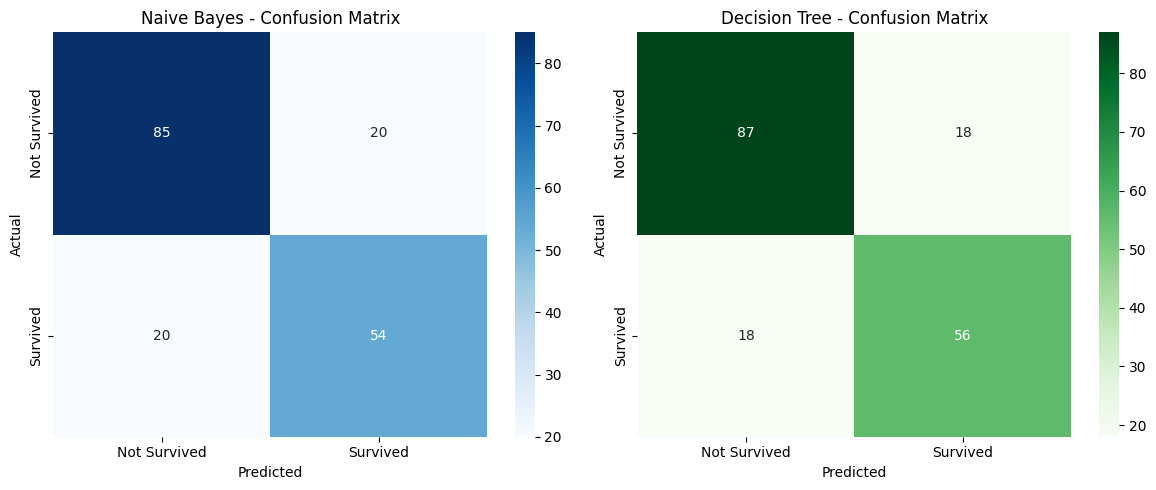

In [21]:
# Step 10
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Naive Bayes heatmap
cm_nb = confusion_matrix(y_test, nb_predictions)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
axes[0].set_title('Naive Bayes - Confusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree heatmap
cm_dt = confusion_matrix(y_test, dt_predictions)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
axes[1].set_title('Decision Tree - Confusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100)
plt.show()
#Decision Tree made 143 correct vs Naive Bayes 139 correct